# Field Identification Dashboard

## Mapping the European Innovation Intermediary Field

This notebook consolidates all visualizations from the **Benabdelkrim et al. (2020)** social curation methodology applied to the EIT Twitter ecosystem.

**Reference:**
> Benabdelkrim, M., Levallois, C., Savinien, J., & Robardet, C. (2020). Opening Fields: A Methodological Contribution to the Identification of Heterogeneous Actors in Unbounded Relational Orders. *M@n@gement*, 23(1), 4-18. https://doi.org/10.37725/mgmt.v23.4245

In [1]:
# Setup
from pathlib import Path
from IPython.display import display, HTML, IFrame, Image, Markdown
import json

# Paths
BASE_DIR = Path().absolute().parent
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = DATA_DIR / "figures"
SIGMA_DIR = FIGURES_DIR / "sigma"

print(f"Base directory: {BASE_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Base directory: C:\Users\babaj\Documents\GitHub\kaobook\dissertation\data\rolebox-social
Figures directory: C:\Users\babaj\Documents\GitHub\kaobook\dissertation\data\rolebox-social\data\figures


---
## 1. Data Overview

Summary of the TweetBinder data processed through the pipeline.

In [2]:
# Load network statistics
stats_file = PROCESSED_DIR / "mention_network_stats.json"
if stats_file.exists():
    with open(stats_file, 'r', encoding='utf-8') as f:
        stats = json.load(f)
    
    display(Markdown(f"""
### Network Statistics

| Metric | Value |
|--------|-------|
| **Total Nodes (Actors)** | {stats['n_nodes']:,} |
| **Total Edges (Mentions)** | {stats['n_edges']:,} |
| **Network Density** | {stats['density']:.6f} |
| **Connected Components** | {stats['n_components']:,} |
| **Largest Component** | {stats['largest_component_size']:,} ({stats['largest_component_pct']:.1f}%) |
| **Reciprocity** | {stats['reciprocity']:.4f} |
"""))
else:
    print("Stats file not found. Run the pipeline first.")


### Network Statistics

| Metric | Value |
|--------|-------|
| **Total Nodes (Actors)** | 65,046 |
| **Total Edges (Mentions)** | 73,879 |
| **Network Density** | 0.000017 |
| **Connected Components** | 38,253 |
| **Largest Component** | 26,371 (40.5%) |
| **Reciprocity** | 0.0015 |


In [3]:
# Load community structure
comm_file = PROCESSED_DIR / "community_structure.json"
if comm_file.exists():
    with open(comm_file, 'r', encoding='utf-8') as f:
        comm_data = json.load(f)
    
    # Get KIC-labeled communities
    kic_comms = [(k, v) for k, v in comm_data['community_labels'].items() 
                 if 'Community_' not in v]
    
    display(Markdown(f"""
### Community Detection Results

| Metric | Value |
|--------|-------|
| **Total Communities** | {comm_data['n_communities']} |
| **Modularity Score** | {comm_data['modularity']:.4f} |
| **KIC-Affiliated Communities** | {len(kic_comms)} |

#### Top 10 Communities by Size
"""))
    
    # Sort communities by size
    sized = [(i, s, comm_data['community_labels'].get(str(i), f'Community_{i}')) 
             for i, s in enumerate(comm_data['community_sizes'])]
    sized.sort(key=lambda x: -x[1])
    
    for i, (idx, size, label) in enumerate(sized[:10]):
        print(f"{i+1}. {label} (n={size:,})")


### Community Detection Results

| Metric | Value |
|--------|-------|
| **Total Communities** | 96 |
| **Modularity Score** | 0.6379 |
| **KIC-Affiliated Communities** | 8 |

#### Top 10 Communities by Size


1. Climate-KIC (n=7,358)
2. EIT Digital (n=3,998)
3. EIT Health (n=3,231)
4. Community_18 (n=2,376)
5. EIT RawMaterials (n=1,935)
6. InnoEnergy (n=1,914)
7. Climate-KIC (n=1,417)
8. Community_74 (n=1,031)
9. Climate-KIC (n=564)
10. Climate-KIC (n=485)


---
## 2. Interactive Network Visualization (Sigma.js)

WebGL-powered interactive network visualization. Features:
- **Zoom/Pan**: Scroll to zoom, drag to pan
- **Search**: Filter nodes by name
- **Hover**: Highlight node and neighbors
- **Click**: View node details

In [4]:
# Display Sigma.js interactive network (local copy)
# Note: HTML files must be in the notebooks directory for Jupyter to serve them
sigma_local = Path("sigma_network.html")

if sigma_local.exists():
    display(IFrame(src="sigma_network.html", width='100%', height='800px'))
else:
    print("Sigma.js visualization not found.")
    print("Copy it with: cp ../data/figures/sigma/network_interactive.html ./sigma_network.html")

---
## 3. Community Characteristics

Comparison of community sizes and internal densities.

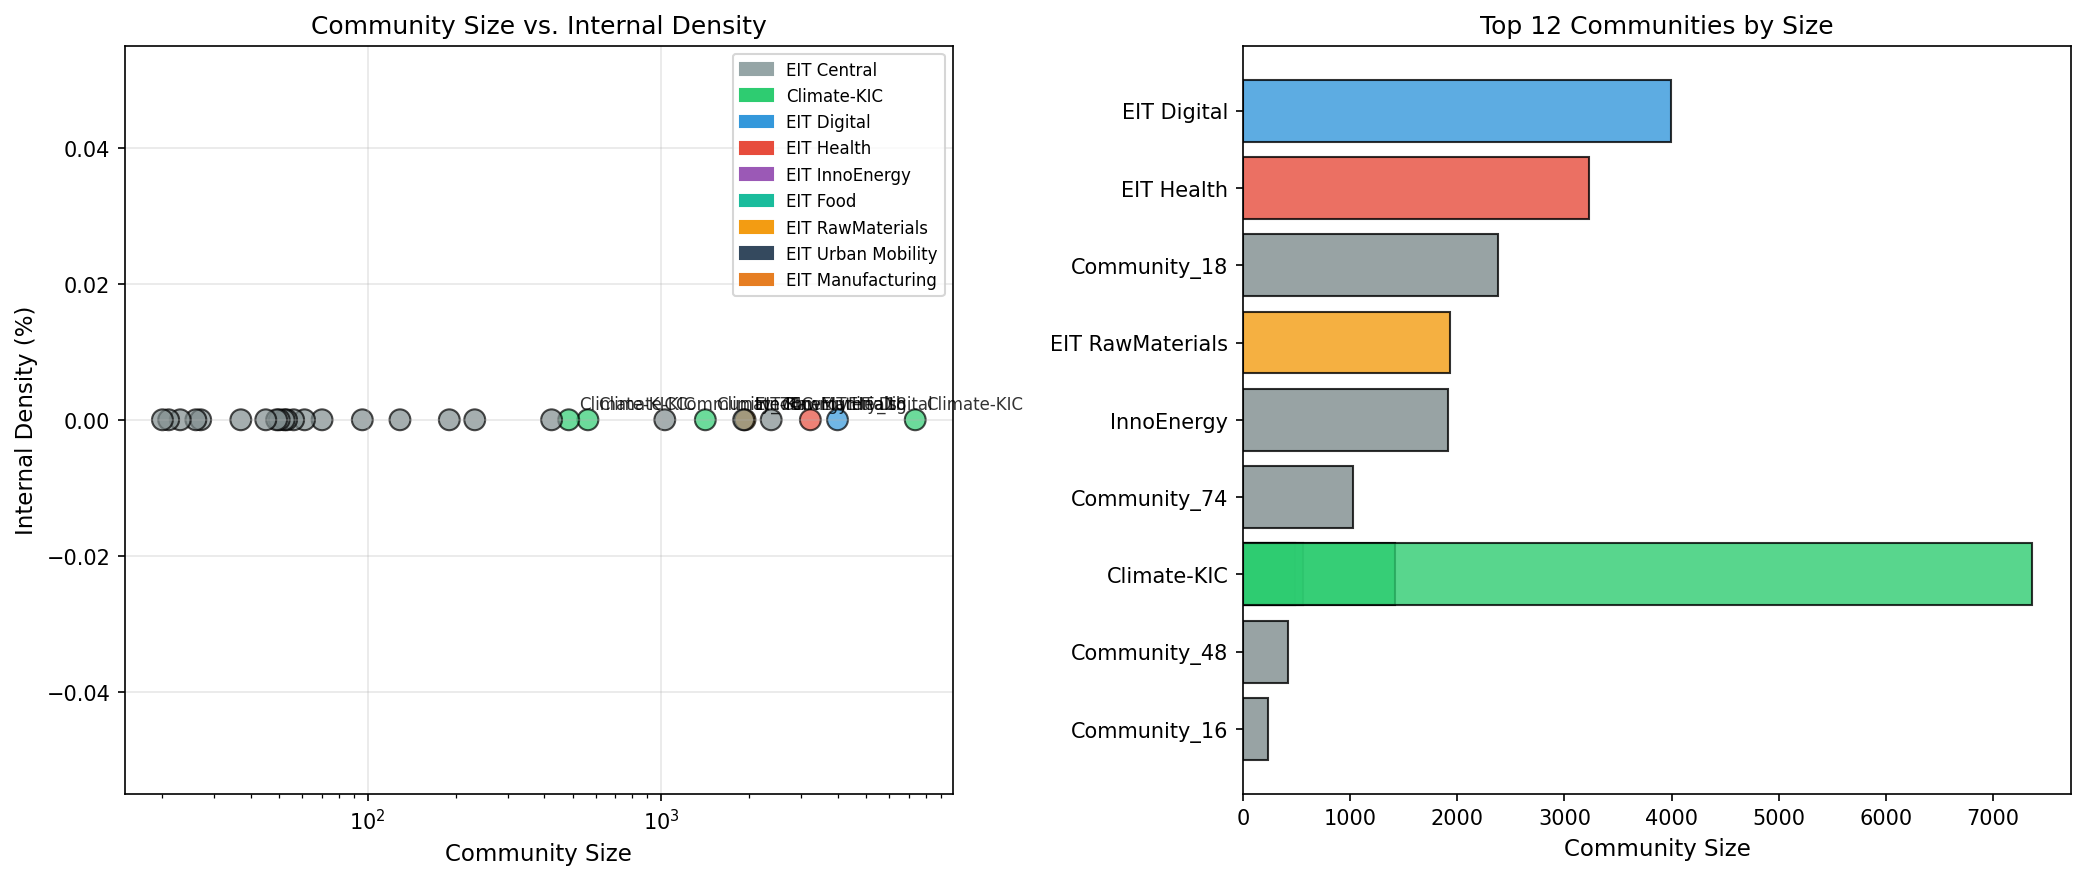

In [5]:
# Display community characteristics plot
comm_plot = FIGURES_DIR / "field_community_characteristics.png"

if comm_plot.exists():
    display(Image(filename=str(comm_plot), width=900))
else:
    print("Community characteristics plot not found.")

---
## 4. Static Network Plot

Publication-quality network visualization (top 200 actors by degree).

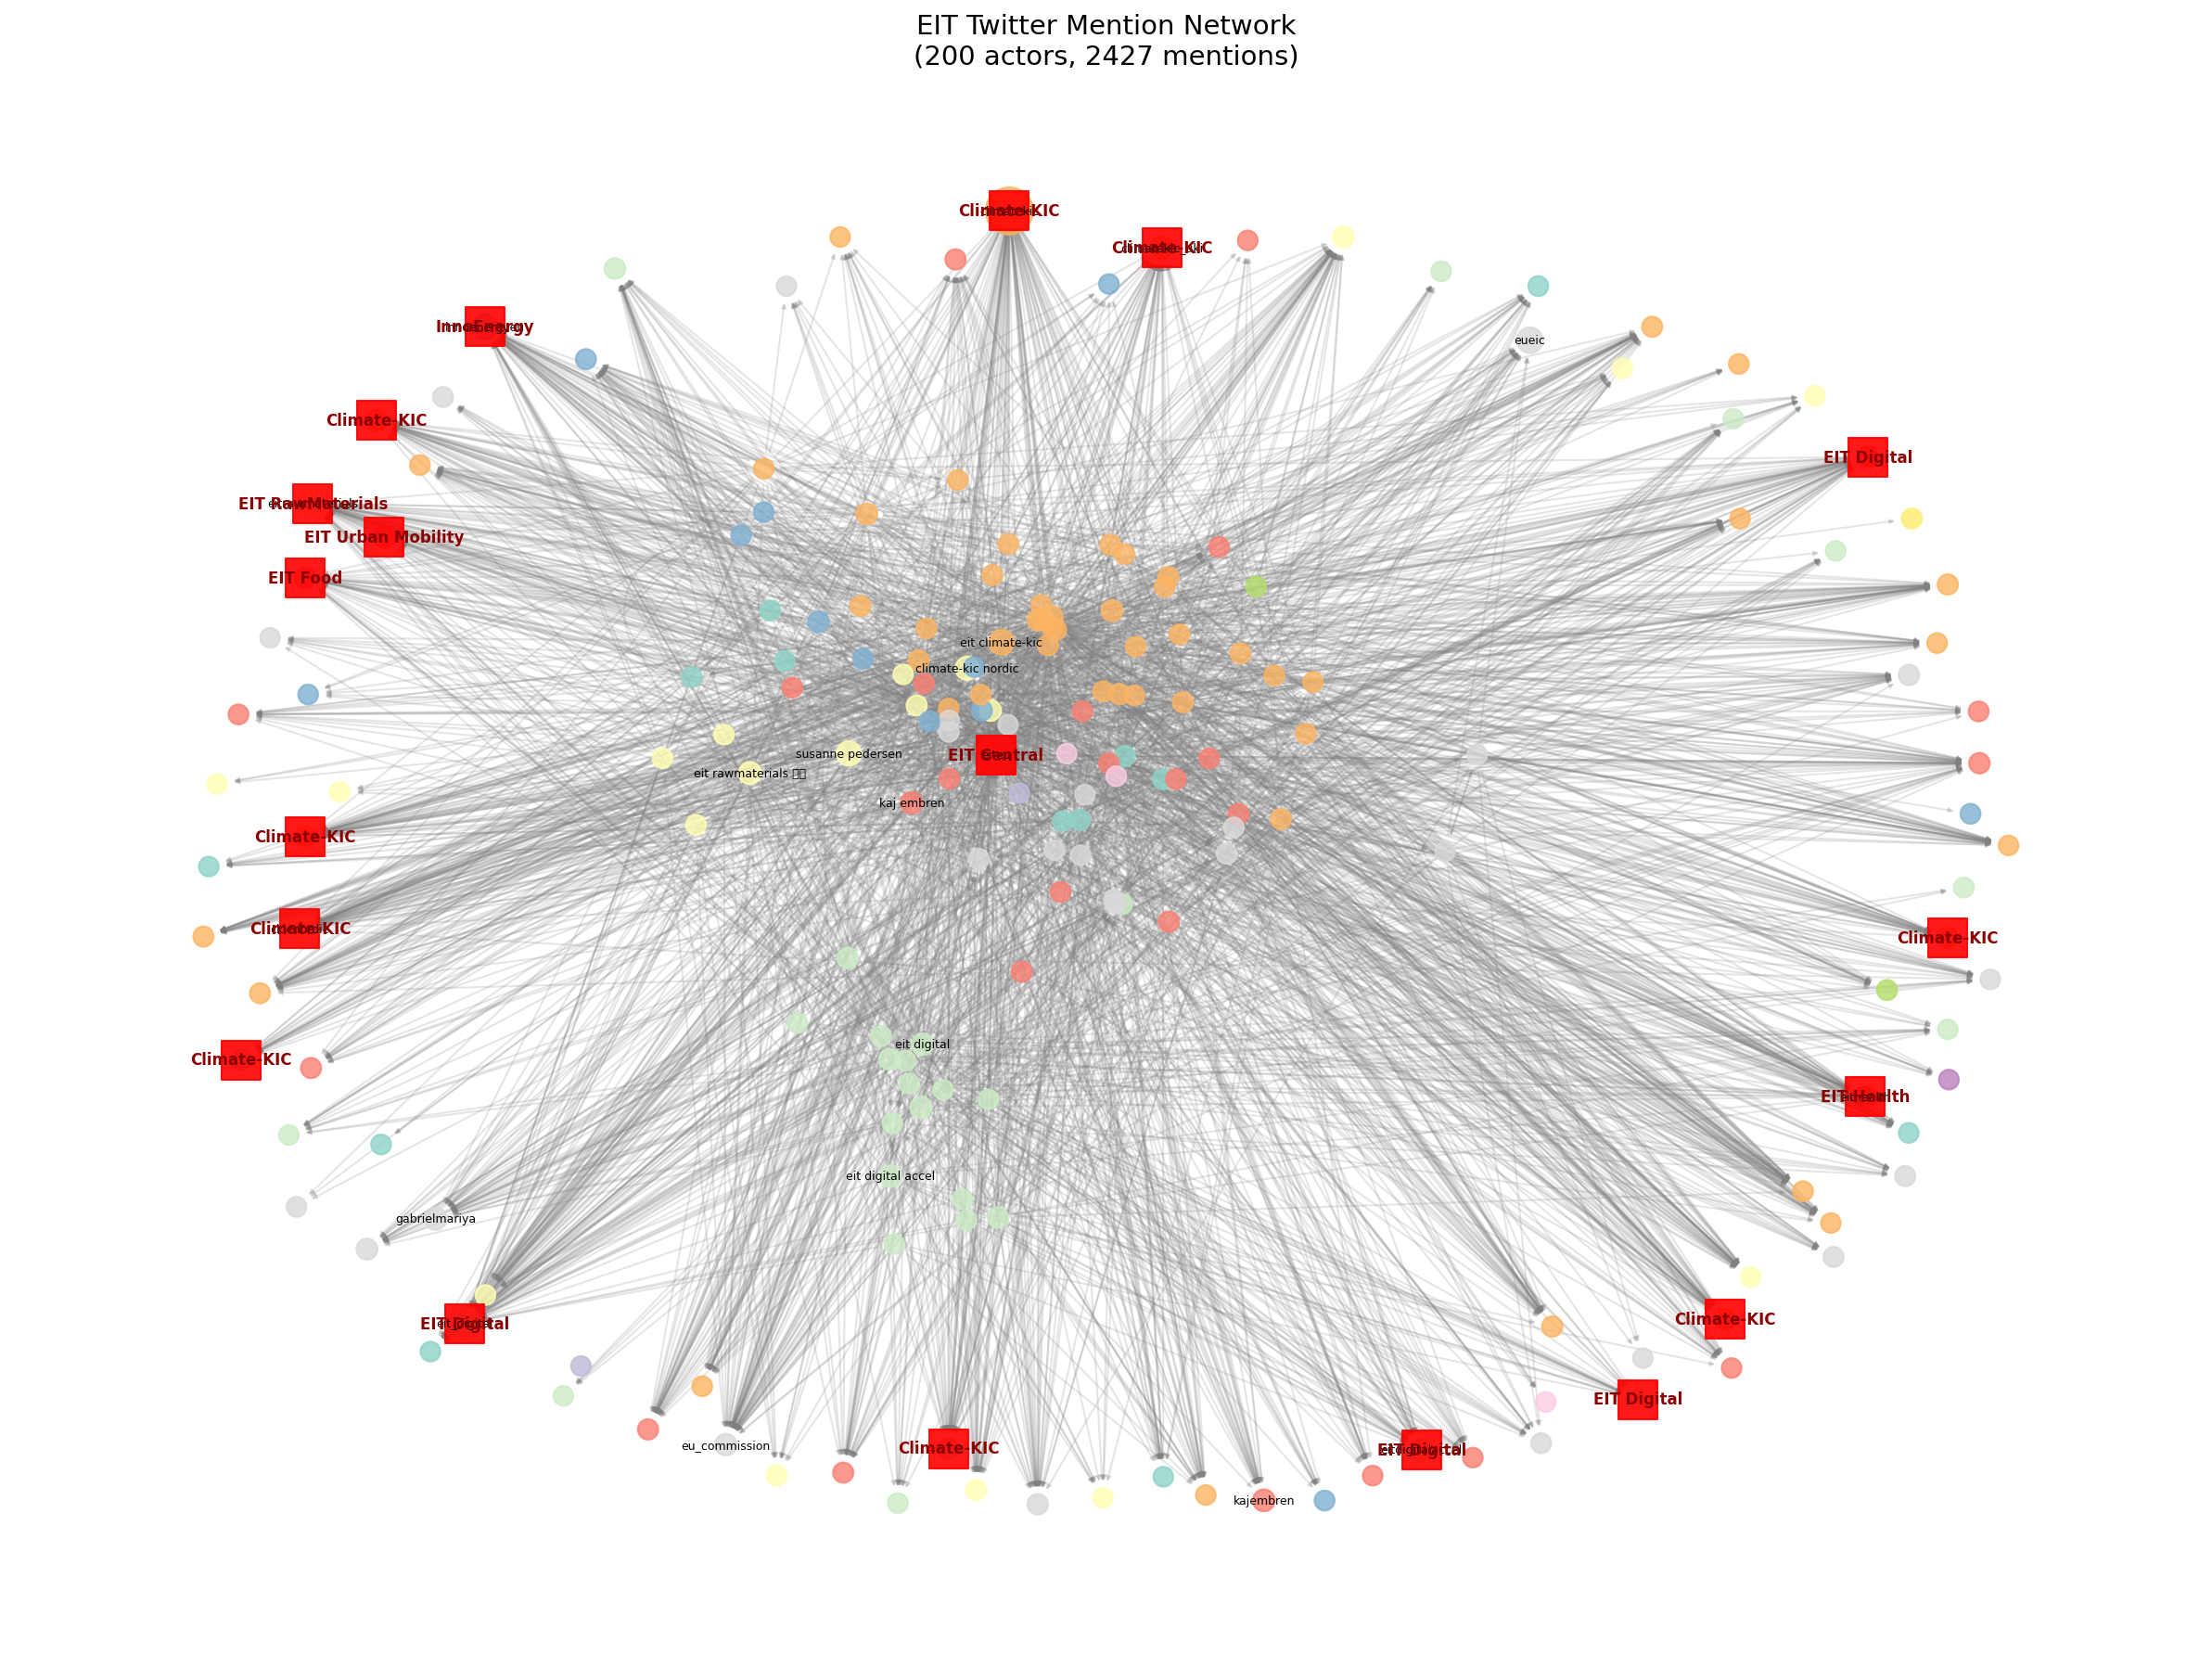

In [6]:
# Display static network plot
network_plot = FIGURES_DIR / "network_plot.png"

if network_plot.exists():
    display(Image(filename=str(network_plot), width=900))
else:
    print("Network plot not found.")

---
## 5. KIC Comparison

Comparison of EIT Knowledge and Innovation Community subnetworks.

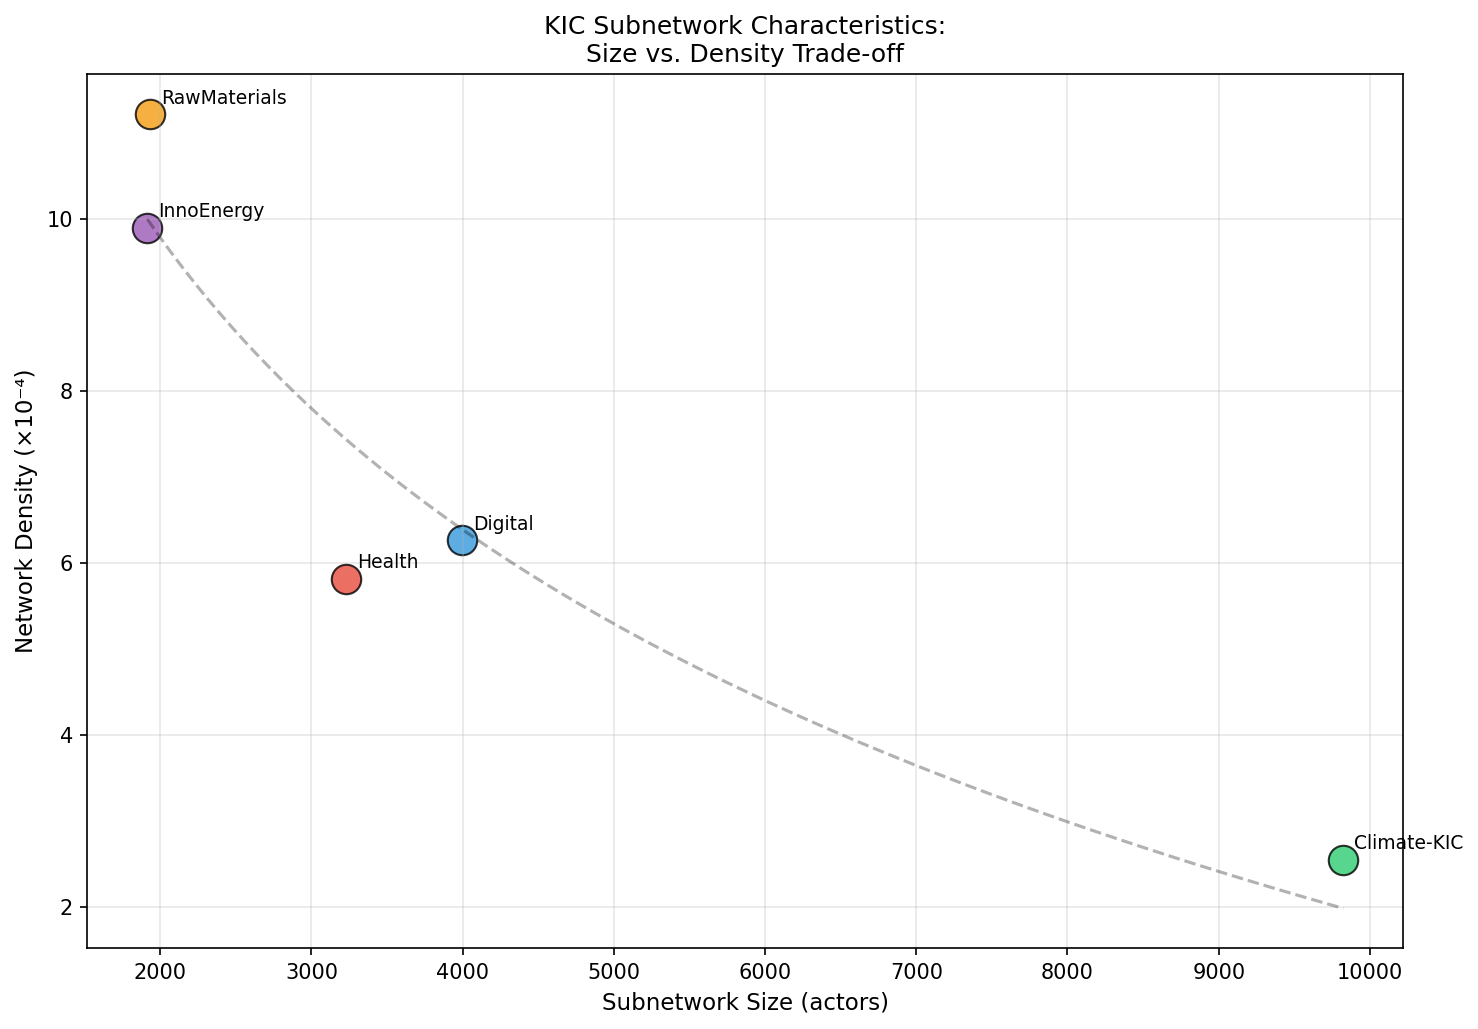

In [7]:
# Display KIC comparison
kic_plot = FIGURES_DIR / "kic_comparison.png"

if kic_plot.exists():
    display(Image(filename=str(kic_plot), width=700))
else:
    print("KIC comparison plot not found.")

---
## 6. Community Sizes Distribution

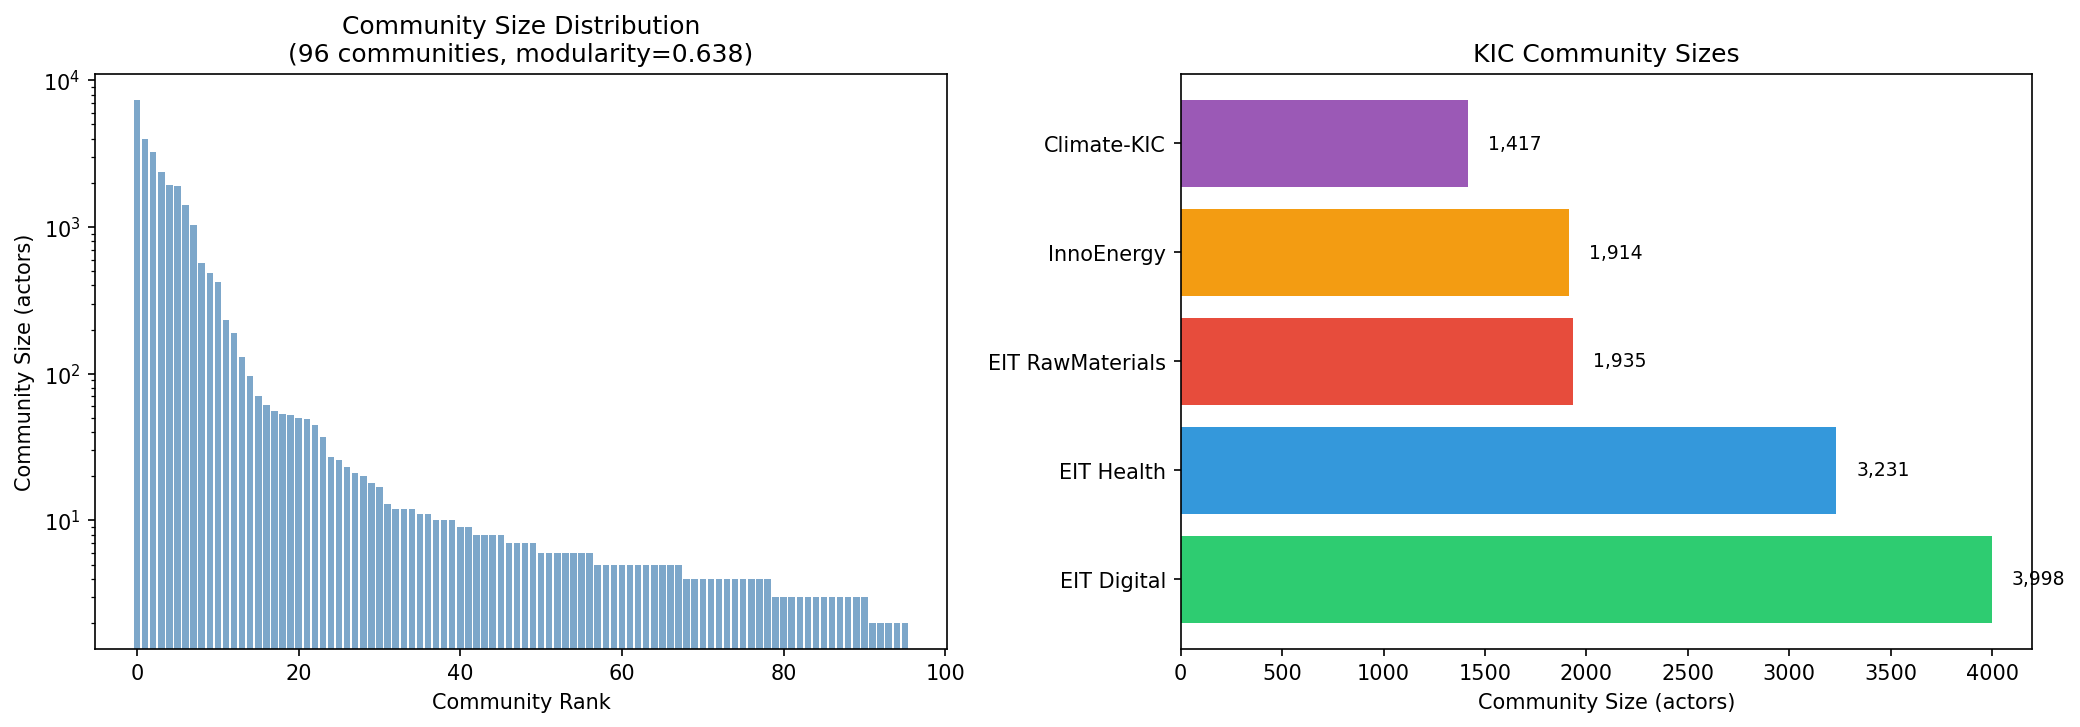

In [8]:
# Display community sizes
comm_sizes_plot = FIGURES_DIR / "community_sizes.png"

if comm_sizes_plot.exists():
    display(Image(filename=str(comm_sizes_plot), width=900))
else:
    print("Community sizes plot not found.")

---
## 7. PyVis Interactive Network

Alternative interactive visualization using PyVis (physics-based layout).

In [9]:
# Display PyVis interactive network (local copy)
pyvis_local = Path("pyvis_network.html")

if pyvis_local.exists():
    display(IFrame(src="pyvis_network.html", width='100%', height='600px'))
else:
    print("PyVis visualization not found.")
    print("Copy it with: cp ../data/figures/network_interactive.html ./pyvis_network.html")

---
## 8. Top Mentioned Actors

Most central actors in the EIT Twitter ecosystem.

In [10]:
# Display top actors
if stats_file.exists():
    display(Markdown("### Top 20 Most Mentioned Accounts\n"))
    
    print(f"{'Rank':<6}{'Account':<30}{'Mentions':>12}")
    print("-" * 50)
    
    for i, (account, count) in enumerate(stats['top_mentioned'][:20]):
        print(f"{i+1:<6}{account:<30}{count:>12,}")

### Top 20 Most Mentioned Accounts


Rank  Account                           Mentions
--------------------------------------------------
1     @climatekic                        104,759
2     @eiteu                              50,294
3     @eit_digital                        39,354
4     @ckicnordic                         19,723
5     @eitrawmaterials                    19,346
6     @innoenergyeu                       12,909
7     @eitdigitalaccel                     9,970
8     @eueic                               9,603
9     @climatesusanne                      7,109
10    @kajembren                           6,170
11    @climatekic_uki                      5,635
12    @climatekicspain                     4,955
13    @eithealth                           4,022
14    @gabrielmariya                       3,997
15    @eitalumni                           3,979
16    @edcentrecc                          3,936
17    @climatelaunch                       3,694
18    @willemjonkernl                      3,691
19    @eiturbanmob

In [11]:
# Display top mentioners
if stats_file.exists():
    display(Markdown("### Top 20 Most Active Mentioners\n"))
    
    print(f"{'Rank':<6}{'Account':<35}{'Mentions Made':>15}")
    print("-" * 58)
    
    for i, (account, count) in enumerate(stats['top_mentioners'][:20]):
        name = account[:32] + '...' if len(account) > 35 else account
        print(f"{i+1:<6}{name:<35}{count:>15,}")

### Top 20 Most Active Mentioners


Rank  Account                              Mentions Made
----------------------------------------------------------
1     @susanne pedersen                           23,334
2     @kaj embren                                 21,693
3     @climate-kic nordic                         18,711
4     @eit climate-kic                            17,734
5     @eit rawmaterials 🇪🇺                         9,486
6     @🇪🇺 edna ayme-yahil 🇺🇸                       7,392
7     @eit digital accel                           7,274
8     @eit digital                                 6,674
9     @miljötweets                                 5,918
10    @line gry knudsen                            5,454
11    @eiteu                                       5,393
12    @climate-kic nl                              4,759
13    @climate-kic spain                           4,751
14    @eit innoenergy                              4,186
15    @stelios yiatros                             4,158
16    @climate-kic germany   

---
## 9. Field Identification Results

Results from the Benabdelkrim et al. methodology.

In [12]:
# Load field identification results
field_results = DATA_DIR / "field_identification" / "field_identification_results.json"

if field_results.exists():
    with open(field_results, 'r', encoding='utf-8') as f:
        results = json.load(f)
    
    display(Markdown(f"""
### Field Identification Summary

| Parameter | Value |
|-----------|-------|
| **Seeds** | {results['metadata']['n_seeds']} |
| **Network Nodes** | {results['network']['n_nodes']:,} |
| **Network Edges** | {results['network']['n_edges']:,} |
| **Communities Detected** | {results['communities']['n_communities']} |

#### Seed Accounts Used:
"""))
    
    for seed in results['metadata']['seeds']:
        print(f"  - {seed['username']} ({seed.get('type', 'unknown')})")
else:
    print("Field identification results not found.")


### Field Identification Summary

| Parameter | Value |
|-----------|-------|
| **Seeds** | 9 |
| **Network Nodes** | 18 |
| **Network Edges** | 0 |
| **Communities Detected** | 18 |

#### Seed Accounts Used:


  - @EITeu (central)
  - @EITClimatekic (institutional)
  - @EITDigital (institutional)
  - @EITHealth (institutional)
  - @InnoEnergy (institutional)
  - @EITFood (institutional)
  - @EITRawMaterials (institutional)
  - @EIT_Urban (institutional)
  - @EITManufacturing (institutional)


---
## 10. Export Links

Direct links to generated files for external use.

In [13]:
# List all generated files
display(Markdown("### Generated Visualization Files\n"))

files_to_check = [
    (SIGMA_DIR / "network_interactive.html", "Sigma.js Interactive Network"),
    (SIGMA_DIR / "network_sigma.json", "Sigma.js JSON Data"),
    (SIGMA_DIR / "network.gexf", "GEXF for Gephi"),
    (FIGURES_DIR / "network_interactive.html", "PyVis Interactive Network"),
    (FIGURES_DIR / "network_plot.png", "Static Network Plot (PNG)"),
    (FIGURES_DIR / "network_plot.pdf", "Static Network Plot (PDF)"),
    (FIGURES_DIR / "community_sizes.png", "Community Sizes Plot"),
    (FIGURES_DIR / "kic_comparison.png", "KIC Comparison Plot"),
    (FIGURES_DIR / "field_community_characteristics.png", "Community Characteristics"),
    (PROCESSED_DIR / "mention_network.graphml", "GraphML Network Export"),
]

print(f"{'Status':<8}{'File Type':<35}{'Path'}")
print("-" * 100)

for path, description in files_to_check:
    status = "[OK]" if path.exists() else "[MISS]"
    rel_path = path.relative_to(BASE_DIR) if path.exists() else path.name
    print(f"{status:<8}{description:<35}{rel_path}")

### Generated Visualization Files


Status  File Type                          Path
----------------------------------------------------------------------------------------------------
[OK]    Sigma.js Interactive Network       data\figures\sigma\network_interactive.html
[OK]    Sigma.js JSON Data                 data\figures\sigma\network_sigma.json
[OK]    GEXF for Gephi                     data\figures\sigma\network.gexf
[OK]    PyVis Interactive Network          data\figures\network_interactive.html
[OK]    Static Network Plot (PNG)          data\figures\network_plot.png
[OK]    Static Network Plot (PDF)          data\figures\network_plot.pdf
[OK]    Community Sizes Plot               data\figures\community_sizes.png
[OK]    KIC Comparison Plot                data\figures\kic_comparison.png
[OK]    Community Characteristics          data\figures\field_community_characteristics.png
[OK]    GraphML Network Export             data\processed\mention_network.graphml


---
## 11. BERTopic Visualizations (if available)

Neural topic modeling results from BERTopic.

In [14]:
# Check for BERTopic visualizations
bertopic_dir = FIGURES_DIR / "visualizations"

bertopic_files = [
    ("topics_barchart.html", "Topic Word Frequencies"),
    ("topics_heatmap.html", "Topic Similarity Heatmap"),
    ("topics_hierarchy.html", "Topic Hierarchy"),
    ("documents_map.html", "Document Embedding Map"),
    ("topics_similarity.html", "Inter-Topic Distances"),
]

if bertopic_dir.exists():
    display(Markdown("### BERTopic Visualizations\n"))
    
    for filename, description in bertopic_files:
        filepath = bertopic_dir / filename
        if filepath.exists():
            display(Markdown(f"#### {description}"))
            display(IFrame(src=str(filepath), width='100%', height='500px'))
else:
    print("BERTopic visualizations not found.")
    print("Run topic_modeling.py to generate them.")

BERTopic visualizations not found.
Run topic_modeling.py to generate them.


---
## Summary

This dashboard presents the results of applying the **Benabdelkrim et al. (2020)** social curation methodology to map the European innovation intermediary field through Twitter mention co-occurrence analysis.

### Key Findings:

1. **Network Scale**: The EIT Twitter ecosystem comprises tens of thousands of actors connected through mention relationships

2. **Community Structure**: Clear modular structure with distinct sub-regions corresponding to different KICs

3. **Central Actors**: Climate-KIC dominates the network, followed by EIT Digital and EIT Central

4. **Field Coherence**: High modularity score indicates meaningful community structure

### Methodology Notes:

- **Data Source**: 268,309 tweets from TweetBinder (2015-2020)
- **Co-classification Proxy**: Mention co-occurrence substitutes for Twitter list co-membership
- **Community Detection**: Louvain algorithm with modularity optimization
- **Visualization**: Sigma.js (WebGL), PyVis, NetworkX, Gephi export